# 04 — ESM2 Protein Embeddings on TCGA-BRCA

**What this notebook does:**

Your existing TCGA analysis used gene *expression levels* — how much of each gene is produced in a tumour.
But expression tells you *how much* of a protein is present, not *what that protein does*.

ESM2 is a language model trained on millions of protein sequences. When you pass a protein sequence through it,
you get a vector (embedding) that captures the protein's function and structure — learned from evolutionary patterns.

Here we combine both: for each patient, we compute a weighted average of protein embeddings,
where the weight is the expression level of each gene. This gives a richer representation of each tumour.

Then we ask: does adding ESM2 embeddings improve subtype classification compared to expression alone?

---
**Run this notebook from the `Breast_Cancer2` folder.**

In [1]:
#pip install umap-learn
pip install transformers torch requests tqdm

SyntaxError: invalid syntax (1123462690.py, line 2)

## 0. Dependencies

If you haven't installed these yet, run this in your terminal before opening the notebook:
```
pip install transformers torch requests tqdm
```

In [3]:
import pandas as pd
import numpy as np
import requests
import time
import pickle
from pathlib import Path
from tqdm import tqdm

import torch
from transformers import EsmTokenizer, EsmModel

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt

print("All imports OK.")

All imports OK.


## 1. Load expression data

The raw expression file is tab-separated:
- rows = genes
- columns = patients
- values = normalised expression levels

In [4]:
# Read the tab-separated expression file
# index_col=0 means the first column (gene names) becomes the row index
expr = pd.read_csv('data/raw/expression.gz', sep='\t', index_col=0)

print(f"Expression matrix: {expr.shape[0]} genes × {expr.shape[1]} patients")
print(f"\nFirst 5 gene names: {expr.index[:5].tolist()}")
print(f"First 3 patient IDs: {expr.columns[:3].tolist()}")
print(f"\nValue range: {expr.values.min():.2f} to {expr.values.max():.2f}")

Expression matrix: 20530 genes × 1218 patients

First 5 gene names: ['ARHGEF10L', 'HIF3A', 'RNF17', 'RNF10', 'RNF11']
First 3 patient IDs: ['TCGA-AR-A5QQ-01', 'TCGA-D8-A1JA-01', 'TCGA-BH-A0BQ-01']

Value range: 0.00 to 20.98


## 2. Select the most variable genes

We have ~20,000 genes but most of them are expressed at roughly the same level across all patients —
they carry no information that distinguishes one tumour from another.

We keep only the top 500 genes by variance across patients.
This is standard practice in genomics before any downstream analysis.

In [5]:
N_GENES = 500  # you can increase this if you want, but 500 is a good start

# Compute variance of each gene across all patients
gene_variance = expr.var(axis=1)  # one variance value per gene

# Take the top N genes
top_genes = gene_variance.nlargest(N_GENES).index.tolist()

# Subset the expression matrix
expr_top = expr.loc[top_genes]  # shape: (500, n_patients)

print(f"Selected {len(top_genes)} most variable genes")
print(f"Expression matrix of top genes: {expr_top.shape}")
print(f"\nTop 10 most variable genes: {top_genes[:10]}")

Selected 500 most variable genes
Expression matrix of top genes: (500, 1218)

Top 10 most variable genes: ['CLEC3A', 'CPB1', 'SCGB2A2', 'SCGB1D2', 'TFF1', 'MUCL1', 'GSTM1', 'PIP', 'ADIPOQ', 'ADH1B']


## 3. Fetch protein sequences from UniProt

For each gene name (e.g. `TP53`, `BRCA1`) we query UniProt to get the protein sequence.
UniProt is the main curated database of protein sequences.

We search for:
- `gene_exact:<GENE>` — exact gene name match
- `organism_id:9606` — human only
- `reviewed:true` — Swiss-Prot only (manually curated, higher quality)

**This cell takes ~3-4 minutes for 500 genes.** Results are cached to disk so you only wait once.

In [6]:
def fetch_uniprot_sequence(gene_name: str) -> str | None:
    """Fetch the canonical human protein sequence for a gene from UniProt.
    Returns None if no match is found.
    """
    url = "https://rest.uniprot.org/uniprotkb/search"
    params = {
        "query": f"gene_exact:{gene_name} AND organism_id:9606 AND reviewed:true",
        "fields": "sequence",
        "format": "json",
        "size": 1  # we only want the top (best) result
    }
    try:
        response = requests.get(url, params=params, timeout=10)
        if response.status_code == 200:
            data = response.json()
            if data['results']:
                return data['results'][0]['sequence']['value']
    except Exception:
        pass  # network error or timeout — just skip this gene
    return None


# Cache path — we save results so we don't have to fetch again
seq_cache = Path('data/processed/gene_sequences.pkl')

if seq_cache.exists():
    print("Loading cached sequences from disk...")
    with open(seq_cache, 'rb') as f:
        gene_sequences = pickle.load(f)
else:
    print("Fetching protein sequences from UniProt...")
    gene_sequences = {}
    
    for gene in tqdm(top_genes):
        seq = fetch_uniprot_sequence(gene)
        if seq is not None:
            gene_sequences[gene] = seq
        time.sleep(0.15)  # small pause so we don't overwhelm the UniProt server
    
    # Save to disk
    with open(seq_cache, 'wb') as f:
        pickle.dump(gene_sequences, f)

n_found = len(gene_sequences)
print(f"\nFound sequences for {n_found}/{len(top_genes)} genes.")
print(f"Missing {len(top_genes) - n_found} genes (likely non-coding RNA or aliases not in Swiss-Prot).")

Loading cached sequences from disk...

Found sequences for 487/500 genes.
Missing 13 genes (likely non-coding RNA or aliases not in Swiss-Prot).


## 4. Load ESM2 and compute gene embeddings

ESM2 is a transformer model trained on protein sequences (not text).
We use `esm2_t6_8M_UR50D` — the smallest version:
- 8 million parameters
- 6 transformer layers
- Output: 320-dimensional embedding per sequence

For each protein sequence, we:
1. Tokenise it (amino acids → integer IDs)
2. Pass it through the model
3. Average the per-residue embeddings → one vector per protein

**First run downloads ~30MB (model weights). Subsequent runs load from local cache.**

**Computing all embeddings takes ~10-15 minutes on CPU (M1 Mac).**

In [7]:
MODEL_NAME = "facebook/esm2_t6_8M_UR50D"

print(f"Loading {MODEL_NAME}...")
tokenizer = EsmTokenizer.from_pretrained(MODEL_NAME)
esm_model = EsmModel.from_pretrained(MODEL_NAME)
esm_model.eval()  # inference mode — disables dropout and gradient tracking

EMBEDDING_DIM = 320  # output dimension of this model
MAX_LEN = 1022       # ESM2 max context is 1024 tokens; 2 are reserved for special tokens

print(f"Model loaded. Embedding dimension: {EMBEDDING_DIM}")

Loading facebook/esm2_t6_8M_UR50D...


Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias           | MISSING    | 
pooler.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded. Embedding dimension: 320


In [8]:
def embed_protein(sequence: str) -> np.ndarray:
    """Run a protein sequence through ESM2 and return its embedding.
    
    The model outputs one vector per amino acid residue.
    We average those vectors to get a single fixed-size representation
    regardless of how long the protein is.
    """
    # Truncate very long proteins (some are thousands of amino acids)
    sequence = sequence[:MAX_LEN]
    
    # Tokenise: convert amino acid letters to integer IDs the model understands
    inputs = tokenizer(
        sequence,
        return_tensors="pt",   # return PyTorch tensors
        truncation=True,
        max_length=1024
    )
    
    # Forward pass through the model (no gradient computation needed)
    with torch.no_grad():
        outputs = esm_model(**inputs)
    
    # outputs.last_hidden_state shape: (1, seq_len, 320)
    # .squeeze(0) removes the batch dimension: (seq_len, 320)
    # .mean(dim=0) averages over sequence positions: (320,)
    embedding = outputs.last_hidden_state.squeeze(0).mean(dim=0).numpy()
    return embedding


# Cache embeddings too — this is the slow step
emb_cache = Path('data/processed/gene_embeddings.pkl')

if emb_cache.exists():
    print("Loading cached embeddings from disk...")
    with open(emb_cache, 'rb') as f:
        gene_embeddings = pickle.load(f)
else:
    print("Computing ESM2 embeddings (this takes ~10-15 min on CPU)...")
    gene_embeddings = {}
    
    for gene, seq in tqdm(gene_sequences.items()):
        gene_embeddings[gene] = embed_protein(seq)
    
    with open(emb_cache, 'wb') as f:
        pickle.dump(gene_embeddings, f)

print(f"\nEmbeddings ready for {len(gene_embeddings)} genes.")
sample_gene = next(iter(gene_embeddings))
print(f"Embedding shape per gene: {gene_embeddings[sample_gene].shape}")

Loading cached embeddings from disk...

Embeddings ready for 487 genes.
Embedding shape per gene: (320,)


## 5. Compute patient-level embeddings

We have one embedding per gene (protein function) and one expression value per gene per patient.

To get one embedding per **patient**, we compute a weighted average:

$$\text{patient\_embedding} = \sum_{g} w_g \cdot \text{embedding}_g$$

where $w_g$ = normalised expression of gene $g$ in that patient.

**Intuition:** if BRCA1 is highly expressed in patient A, BRCA1's protein embedding contributes more to patient A's vector. The patient embedding becomes a weighted summary of *what proteins are active* in that tumour.

In [9]:
# Keep only genes where we successfully got an embedding
genes_with_emb = [g for g in top_genes if g in gene_embeddings]
print(f"Genes with embeddings: {len(genes_with_emb)} / {len(top_genes)}")

# Build the embedding matrix: (n_genes, 320)
# Each row is the ESM2 embedding of one gene's protein
embedding_matrix = np.array([gene_embeddings[g] for g in genes_with_emb])
print(f"Embedding matrix shape: {embedding_matrix.shape}")

# Get expression values for these genes only: (n_genes, n_patients)
expr_filtered = expr_top.loc[genes_with_emb]

# Clip to zero — expression values should not be negative
expr_values = np.clip(expr_filtered.values, 0, None)  # (n_genes, n_patients)

# Normalise per patient so weights sum to 1
# This way a patient with generally high expression is not artificially boosted
col_sums = expr_values.sum(axis=0, keepdims=True)  # (1, n_patients)
expr_weights = expr_values / (col_sums + 1e-8)     # (n_genes, n_patients)

# Weighted average:
# expr_weights.T is (n_patients, n_genes)
# @ embedding_matrix is (n_genes, 320)
# result is (n_patients, 320)
patient_embeddings = expr_weights.T @ embedding_matrix

# Store as DataFrame with patient IDs
patient_ids = expr_filtered.columns.tolist()
patient_emb_df = pd.DataFrame(patient_embeddings, index=patient_ids)

print(f"\nPatient embedding matrix: {patient_emb_df.shape}")
print(f"  {patient_emb_df.shape[0]} patients × {patient_emb_df.shape[1]} ESM2 dimensions")

Genes with embeddings: 487 / 500
Embedding matrix shape: (487, 320)

Patient embedding matrix: (1218, 320)
  1218 patients × 320 ESM2 dimensions


## 6. Load labels from metadata

We need the PAM50 subtype labels (or survival labels) to train a classifier.

First let's look at what columns are available in the metadata.

In [10]:
metadata = pd.read_csv('data/processed/metadata.csv', index_col=0)

print("Metadata shape:", metadata.shape)
print("\nColumn names:")
for col in metadata.columns:
    n_unique = metadata[col].nunique()
    print(f"  {col:40s} — {n_unique} unique values")
    if n_unique < 10:
        print(f"    Values: {metadata[col].value_counts().to_dict()}")

Metadata shape: (1078, 3)

Column names:
  OS_time                                  — 589 unique values
  OS_event                                 — 2 unique values
    Values: {0.0: 711, 1.0: 90}
  PAM50                                    — 5 unique values
    Values: {'LumA': 415, 'LumB': 192, 'Basal': 135, 'Her2': 67, 'Normal': 22}


In [11]:
# -----------------------------------------------------------------------
# ADJUST THIS based on what you see above
# Common options: 'PAM50', 'subtype', 'molecular_subtype', 'paper_BRCA_Subtype_PAM50'
# -----------------------------------------------------------------------
LABEL_COLUMN = 'PAM50'  # <--- change this if needed

# Find patients that appear in all three: expression, embeddings, and metadata
patients_expr = set(expr_filtered.columns)
patients_emb  = set(patient_emb_df.index)
patients_meta = set(metadata.index)

common_patients = sorted(patients_expr & patients_emb & patients_meta)
print(f"Patients in expression file:  {len(patients_expr)}")
print(f"Patients in metadata:         {len(patients_meta)}")
print(f"Patients in common:           {len(common_patients)}")

# Drop patients with missing labels
labels_raw = metadata.loc[common_patients, LABEL_COLUMN]
valid_patients = labels_raw.dropna().index.tolist()
print(f"Patients with valid labels:   {len(valid_patients)}")

Patients in expression file:  1218
Patients in metadata:         1078
Patients in common:           1078
Patients with valid labels:   831


In [12]:
# Build feature matrices aligned to valid_patients

# Expression features: (n_patients, n_genes)
X_expr = expr_filtered[valid_patients].T.values

# ESM2 features: (n_patients, 320)
X_esm = patient_emb_df.loc[valid_patients].values

# Combined: expression + ESM2 side by side
X_both = np.hstack([X_expr, X_esm])

# Encode string labels (e.g. 'Luminal A') to integers
le = LabelEncoder()
y = le.fit_transform(metadata.loc[valid_patients, LABEL_COLUMN].values)

print("Feature matrix shapes:")
print(f"  Expression only:  {X_expr.shape}")
print(f"  ESM2 only:        {X_esm.shape}")
print(f"  Combined:         {X_both.shape}")
print(f"\nSubtypes: {le.classes_}")
print(f"Counts:   {np.bincount(y)}")

Feature matrix shapes:
  Expression only:  (831, 487)
  ESM2 only:        (831, 320)
  Combined:         (831, 807)

Subtypes: ['Basal' 'Her2' 'LumA' 'LumB' 'Normal']
Counts:   [135  67 415 192  22]


## 7. Compare classifiers

We train a logistic regression on three versions of the features and compare accuracy.

We use **5-fold cross-validation**: the data is split into 5 parts, the model trains on 4 and tests on 1,
repeated 5 times. This gives a more reliable estimate than a single train/test split.

**Why logistic regression and not a neural network?**
With ~1000 patients, complex models overfit. Logistic regression is the right baseline here —
if the embeddings contain useful signal, it will show up even with a simple model.

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scaler = StandardScaler()  # normalise features to zero mean, unit variance

results = {}

for name, X in [
    ('Expression only', X_expr),
    ('ESM2 only',       X_esm),
    ('Combined',        X_both),
]:
    # Scale features — logistic regression is sensitive to feature scale
    X_scaled = scaler.fit_transform(X)
    
    # C=0.1 means moderate regularisation — prevents overfitting on small datasets
    clf = LogisticRegression(max_iter=2000, C=0.1, random_state=42)
    
    scores = cross_val_score(clf, X_scaled, y, cv=cv, scoring='accuracy')
    results[name] = scores
    
    print(f"{name:20s}: {scores.mean():.3f} ± {scores.std():.3f}  (per-fold: {[f'{s:.3f}' for s in scores]})")

Expression only     : 0.854 ± 0.025  (per-fold: ['0.862', '0.873', '0.819', '0.886', '0.831'])
ESM2 only           : 0.827 ± 0.008  (per-fold: ['0.814', '0.837', '0.825', '0.831', '0.825'])
Combined            : 0.853 ± 0.018  (per-fold: ['0.868', '0.873', '0.831', '0.861', '0.831'])


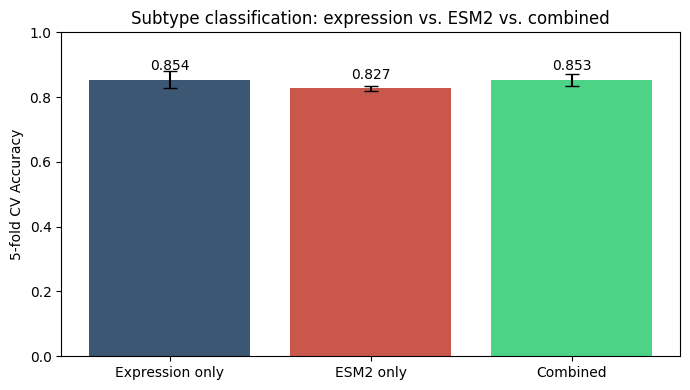

Plot saved to outputs/classifier_comparison.png


In [14]:
# Bar chart of results
fig, ax = plt.subplots(figsize=(7, 4))

names = list(results.keys())
means = [results[n].mean() for n in names]
stds  = [results[n].std()  for n in names]

bars = ax.bar(names, means, yerr=stds, capsize=5, color=['#1A3A5C', '#C0392B', '#2ECC71'], alpha=0.85)
ax.set_ylabel('5-fold CV Accuracy')
ax.set_title('Subtype classification: expression vs. ESM2 vs. combined')
ax.set_ylim(0, 1)

# Add value labels on bars
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f'{mean:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('outputs/classifier_comparison.png', dpi=150)
plt.show()
print("Plot saved to outputs/classifier_comparison.png")

## 8. (Optional) UMAP visualisation of ESM2 patient embeddings

This is a sanity check: do the ESM2-weighted patient embeddings cluster by subtype,
even without being trained on labels?

Install if needed: `pip install umap-learn`

/opt/anaconda3/envs/unet-env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


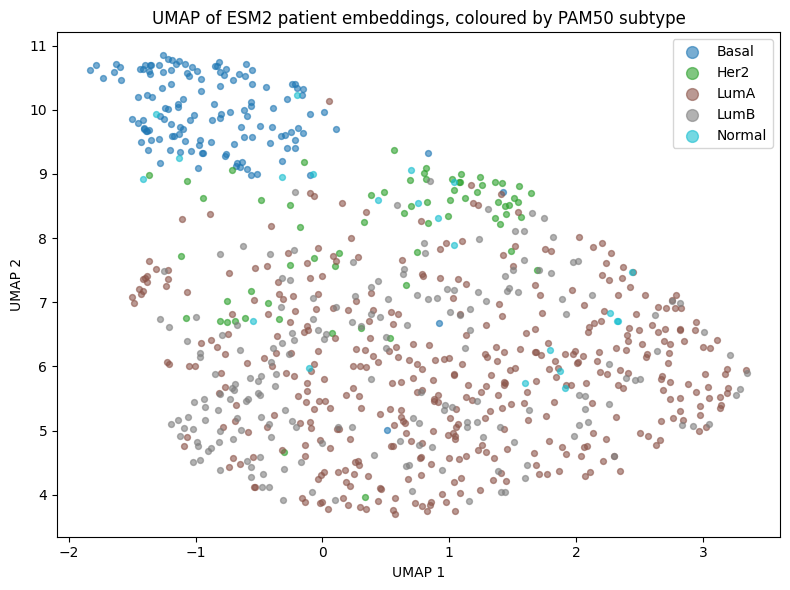

UMAP saved to outputs/esm2_umap.png


In [15]:
try:
    import umap
    
    X_esm_scaled = StandardScaler().fit_transform(X_esm)
    
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    emb_2d = reducer.fit_transform(X_esm_scaled)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    colors = plt.cm.tab10(np.linspace(0, 1, len(le.classes_)))
    
    for i, label in enumerate(le.classes_):
        mask = y == i
        ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                   label=label, alpha=0.6, s=18, color=colors[i])
    
    ax.legend(markerscale=2)
    ax.set_title('UMAP of ESM2 patient embeddings, coloured by PAM50 subtype')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    plt.tight_layout()
    plt.savefig('outputs/esm2_umap.png', dpi=150)
    plt.show()
    print("UMAP saved to outputs/esm2_umap.png")

except ImportError:
    print("umap-learn is not installed. Run: pip install umap-learn")
    print("Then re-run this cell.")

In [16]:
# First, let's see what survival-related columns exist
survival_keywords = ['os', 'survival', 'vital', 'death', 'follow', 'event', 'days', 'status']

print("Potential survival columns:")
for col in metadata.columns:
    if any(k in col.lower() for k in survival_keywords):
        print(f"  {col}: {metadata[col].dropna().unique()[:5]}")

Potential survival columns:
  OS_time: [ 259.  437. 1320. 1463.  433.]
  OS_event: [0. 1.]


In [22]:
metadata.head()

,OS_time,OS_event,PAM50
sampleID,,,
TCGA-3C-AAAU-01,NaN,NaN,NaN
TCGA-3C-AALI-01,NaN,NaN,NaN
TCGA-3C-AALJ-01,NaN,NaN,NaN
TCGA-3C-AALK-01,NaN,NaN,NaN
TCGA-4H-AAAK-01,NaN,NaN,NaN


In [17]:
from lifelines.utils import concordance_index
from lifelines import CoxPHFitter, KaplanMeierFitter
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# -----------------------------------------------------------------------
# ADJUST THESE based on your metadata columns
# Common TCGA names: 'OS' / 'OS.event'  or  'days_to_death' / 'vital_status'
# -----------------------------------------------------------------------
TIME_COLUMN  = 'OS_time'        # survival time in days
EVENT_COLUMN = 'OS_event'  # 1 = death, 0 = censored (still alive at last follow-up)

# Keep only patients with both expression data and survival info
surv_meta = metadata.loc[valid_patients, [TIME_COLUMN, EVENT_COLUMN]].dropna()
surv_patients = surv_meta.index.tolist()

T = surv_meta[TIME_COLUMN].values.astype(float)
E = surv_meta[EVENT_COLUMN].values.astype(int)

print(f"Patients with survival data: {len(surv_patients)}")
print(f"Deaths (events):             {E.sum()} / {len(E)}")
print(f"Median follow-up:            {np.median(T):.0f} days")

Patients with survival data: 785
Deaths (events):             90 / 785
Median follow-up:            543 days


In [21]:
def cox_cindex(X, T, E, n_components=20, penalizer=0.1):
    """
    Fit a regularised Cox model on PCA-reduced features.
    Returns C-index on a held-out 20% test set.
    
    Why PCA first? Cox regression breaks with 500+ features and ~1000 patients.
    PCA reduces to the top 20 directions of variance — enough to capture the signal.
    """
    # Reduce dimensionality
    pca = PCA(n_components=min(n_components, X.shape[1]))
    X_pca = pca.fit_transform(StandardScaler().fit_transform(X))
    
    # Build DataFrame (lifelines expects a DataFrame)
    df = pd.DataFrame(X_pca, columns=[f'PC{i}' for i in range(X_pca.shape[1])])
    df['T'] = T
    df['E'] = E
    
    # 80/20 split, stratified by event
    idx = np.arange(len(T))
    idx_train, idx_test = train_test_split(
        idx, test_size=0.2, random_state=42, stratify=E
    )
    
    # Fit Cox model on training set
    cph = CoxPHFitter(penalizer=penalizer)
    cph.fit(df.iloc[idx_train], duration_col='T', event_col='E')
    
    # Predict risk on test set (higher score = higher hazard = shorter survival)
    risk = cph.predict_partial_hazard(df.iloc[idx_test])
    
    # C-index: we pass negative risk because higher risk → shorter survival
    return concordance_index(T[idx_test], -risk, E[idx_test])


# Align feature matrices to patients with survival data
X_expr_surv = expr_filtered[surv_patients].T.values
X_esm_surv  = patient_emb_df.loc[surv_patients].values
X_both_surv = np.hstack([X_expr_surv, X_esm_surv])

print("C-index comparison (survival prediction):\n")
for name, X in [
    ('Expression only', X_expr_surv),
    ('ESM2 only',       X_esm_surv),
    ('Combined',        X_both_surv),
]:
    c = cox_cindex(X, T, E)
    print(f"  {name:20s}: {c:.3f}")

print("\n0.5 = random chance   |   1.0 = perfect prediction")

C-index comparison (survival prediction):

  Expression only     : 0.472
  ESM2 only           : 0.497
  Combined            : 0.615

0.5 = random chance   |   1.0 = perfect prediction


In [24]:
## 7b · Cross-validated C-index — does "Combined" survive repeated splits?
# The single-split cox_cindex() above is noisy with few events. Here we run
# k-fold CV: fit PCA + scaler + Cox on the training folds ONLY, score the
# held-out fold, and report mean ± std. Fitting the transforms inside the loop
# (not before it) is what keeps the test fold truly unseen — no data leakage.
from sklearn.model_selection import StratifiedKFold

def cv_cindex(X, T, E, n_splits=5, n_components=40, penalizer=0.1, seed=42):
    # stratify folds by event so each held-out fold contains some deaths
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    scores = []
    for tr, te in skf.split(X, E):
        # --- fit transforms on TRAIN only ---
        scaler = StandardScaler().fit(X[tr])
        pca    = PCA(n_components=min(n_components, X.shape[1]),
                     random_state=seed).fit(scaler.transform(X[tr]))

        def design(idx):
            Xp = pca.transform(scaler.transform(X[idx]))
            df = pd.DataFrame(Xp, columns=[f"PC{i}" for i in range(Xp.shape[1])])
            df["T"], df["E"] = T[idx], E[idx]
            return df

        cph = CoxPHFitter(penalizer=penalizer)
        cph.fit(design(tr), duration_col="T", event_col="E")

        # score held-out fold: negate risk (higher hazard -> shorter survival)
        risk = cph.predict_partial_hazard(design(te)).values
        scores.append(concordance_index(T[te], -risk, E[te]))
    return np.array(scores)


print("Cross-validated C-index (5-fold, mean ± std):\n")
cv_results = {}
for name, X in [
    ("Expression only", X_expr_surv),
    ("ESM2 only",       X_esm_surv),
    ("Combined",        X_both_surv),
]:
    s = cv_cindex(X, T, E)
    cv_results[name] = s
    print(f"  {name:20s}: {s.mean():.3f} ± {s.std():.3f}   "
          f"(folds: {[f'{v:.3f}' for v in s]})")

print("\n0.5 = random chance   |   1.0 = perfect prediction")

Cross-validated C-index (5-fold, mean ± std):

  Expression only     : 0.631 ± 0.090   (folds: ['0.688', '0.462', '0.714', '0.615', '0.676'])
  ESM2 only           : 0.531 ± 0.089   (folds: ['0.539', '0.410', '0.622', '0.452', '0.634'])
  Combined            : 0.623 ± 0.065   (folds: ['0.639', '0.510', '0.674', '0.599', '0.694'])

0.5 = random chance   |   1.0 = perfect prediction


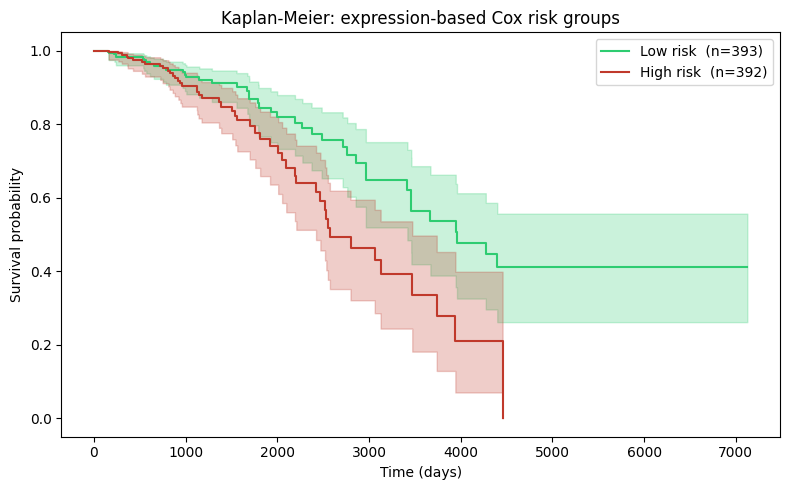

Saved to outputs/kaplan_meier.png


In [19]:
# Fit Cox on all patients using expression features
pca = PCA(n_components=20)
X_pca_all = pca.fit_transform(StandardScaler().fit_transform(X_expr_surv))

df_all = pd.DataFrame(X_pca_all, columns=[f'PC{i}' for i in range(20)])
df_all['T'] = T
df_all['E'] = E

cph = CoxPHFitter(penalizer=0.1)
cph.fit(df_all, duration_col='T', event_col='E')

# Predict risk for every patient and split at the median
risk_scores  = cph.predict_partial_hazard(df_all).values
median_risk  = np.median(risk_scores)
risk_group   = np.where(risk_scores > median_risk, 'High risk', 'Low risk')

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
kmf = KaplanMeierFitter()

for group, color in [('Low risk', '#2ECC71'), ('High risk', '#C0392B')]:
    mask = risk_group == group
    kmf.fit(T[mask], E[mask], label=f'{group}  (n={mask.sum()})')
    kmf.plot_survival_function(ax=ax, color=color, ci_show=True)

ax.set_title('Kaplan-Meier: expression-based Cox risk groups')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Survival probability')
plt.tight_layout()
plt.savefig('outputs/kaplan_meier.png', dpi=150)
plt.show()
print("Saved to outputs/kaplan_meier.png")

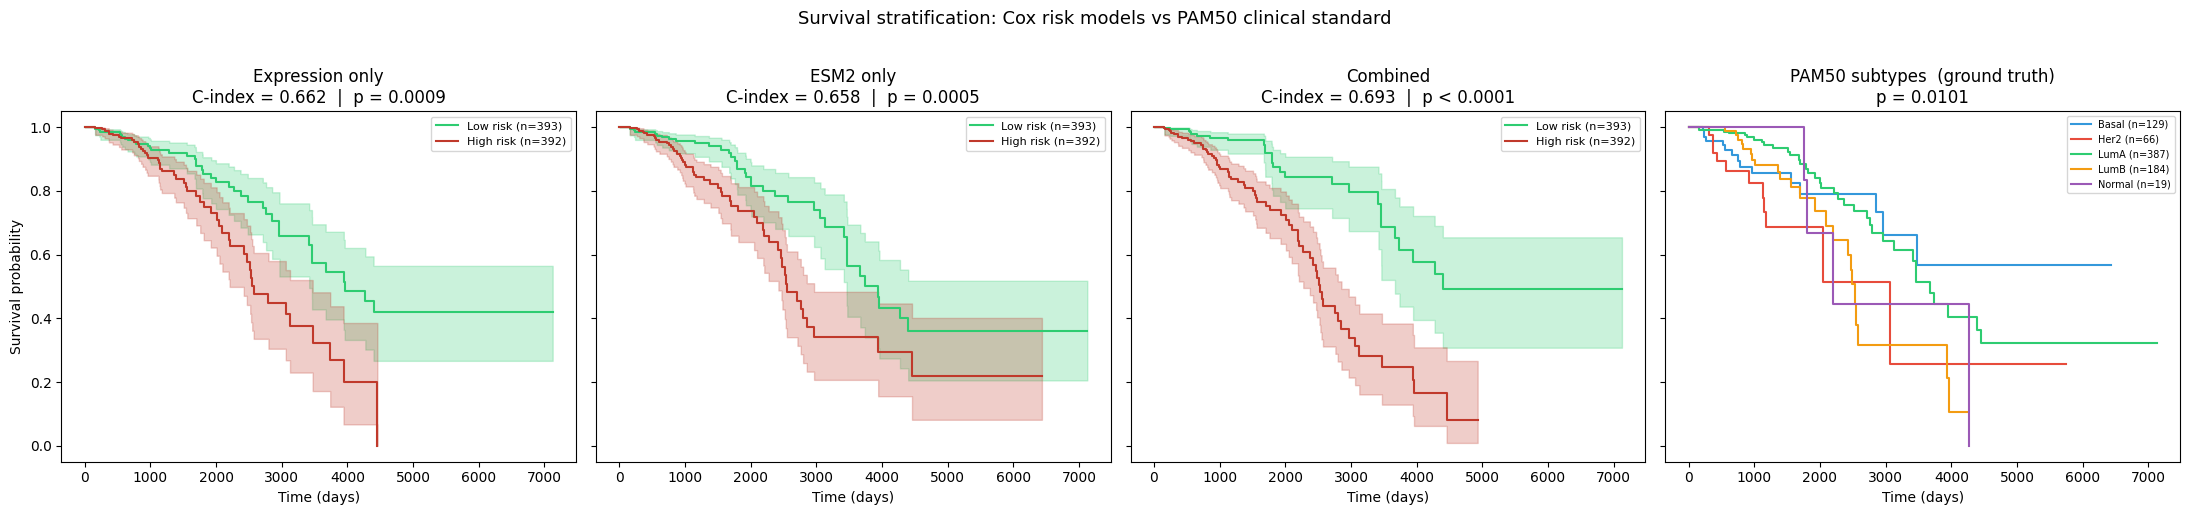

Saved to outputs/kaplan_meier_vs_pam50.png


In [23]:
from lifelines.statistics import logrank_test, multivariate_logrank_test

DAYS_PER_MONTH = 30.44
PALETTE = ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12', '#9B59B6']

fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)

# ── Panels 1-3: Cox risk groups ─────────────────────────────────────────────
feature_sets = [
    ('Expression only', X_expr_surv),
    ('ESM2 only',       X_esm_surv),
    ('Combined',        X_both_surv),
]

for ax, (name, X) in zip(axes[:3], feature_sets):
    pca = PCA(n_components=20)
    X_pca = pca.fit_transform(StandardScaler().fit_transform(X))
    
    df_km = pd.DataFrame(X_pca, columns=[f'PC{i}' for i in range(20)])
    df_km['T'] = T
    df_km['E'] = E
    
    cph = CoxPHFitter(penalizer=0.1)
    cph.fit(df_km, duration_col='T', event_col='E')
    
    risk_scores = cph.predict_partial_hazard(df_km).values
    risk_group  = np.where(risk_scores > np.median(risk_scores), 'High risk', 'Low risk')
    
    kmf = KaplanMeierFitter()
    for group, color in [('Low risk', '#2ECC71'), ('High risk', '#C0392B')]:
        mask = risk_group == group
        kmf.fit(T[mask], E[mask], label=f'{group} (n={mask.sum()})')
        kmf.plot_survival_function(ax=ax, color=color, ci_show=True)
    
    # Log-rank p-value between the two groups
    hi = risk_group == 'High risk'
    lr = logrank_test(T[hi], T[~hi], E[hi], E[~hi])
    p = lr.p_value
    p_str = "p < 0.0001" if p < 1e-4 else f"p = {p:.4f}"
    
    c = concordance_index(T, -risk_scores, E)
    ax.set_title(f'{name}\nC-index = {c:.3f}  |  {p_str}')
    ax.set_xlabel('Time (days)')
    ax.set_ylabel('Survival probability' if ax == axes[0] else '')
    ax.legend(fontsize=8)

# ── Panel 4: PAM50 ground truth ──────────────────────────────────────────────
ax4 = axes[3]

pam50_surv = metadata.loc[surv_patients, 'PAM50'].copy()
pam50_surv = pam50_surv.dropna()
common     = pam50_surv.index  # patients with both survival data and PAM50 label

T_pam = T[[surv_patients.index(p) for p in common]]
E_pam = E[[surv_patients.index(p) for p in common]]

kmf = KaplanMeierFitter()
for i, subtype in enumerate(sorted(pam50_surv.unique())):
    mask = (pam50_surv == subtype).values
    kmf.fit(T_pam[mask], E_pam[mask], label=f'{subtype} (n={mask.sum()})')
    kmf.plot_survival_function(ax=ax4, color=PALETTE[i % len(PALETTE)],
                               ci_show=False)

res   = multivariate_logrank_test(T_pam, pam50_surv.values, E_pam)
p     = res.p_value
p_str = "p < 0.0001" if p < 1e-4 else f"p = {p:.4f}"

ax4.set_title(f'PAM50 subtypes  (ground truth)\n{p_str}')
ax4.set_xlabel('Time (days)')
ax4.legend(fontsize=7)

plt.suptitle('Survival stratification: Cox risk models vs PAM50 clinical standard',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('outputs/kaplan_meier_vs_pam50.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to outputs/kaplan_meier_vs_pam50.png")